# Task 4: FinTech Transaction Fraud Detection

An end-to-end transaction-risk pipeline for rare-event fraud screening. It uses temporal validation, leak-resistant feature handling, tuned gradient boosting, and explainability diagnostics.

> **Google Colab:** Upload `Task 4` to `MyDrive/Thiranex/Task 4`, then run all cells.


In [1]:
import sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install -q pandas numpy scikit-learn matplotlib seaborn joblib
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    candidates = [Path('/content/drive/MyDrive/Thiranex/Task 4'), Path('/content/drive/MyDrive/Task 4'), Path('/content/Task 4')]
    PROJECT_ROOT = next((path for path in candidates if path.exists()), None)
    if PROJECT_ROOT is None:
        raise FileNotFoundError('Upload Task 4 to MyDrive/Thiranex/Task 4 and rerun.')
else:
    PROJECT_ROOT = Path.cwd().resolve()
    if PROJECT_ROOT.name == 'notebooks': PROJECT_ROOT = PROJECT_ROOT.parent

SRC = PROJECT_ROOT / 'src'
if str(SRC) not in sys.path: sys.path.insert(0, str(SRC))
from data_cleaning import run_preparation_pipeline
from modeling import evaluate_model, fit_comparison, permutation_feature_importance, save_model, temporal_split, tune_gradient_boosting
from visualization import generate_diagnostics

RAW_PATH = PROJECT_ROOT / 'data/raw/credit_card_fraud_detection_500k.csv'
PROCESSED_PATH = PROJECT_ROOT / 'data/processed/task4_transactions_prepared.csv'
FIGURES_DIR = PROJECT_ROOT / 'reports/figures'
MODEL_PATH = PROJECT_ROOT / 'models/tuned_fraud_detector.joblib'
print(f'Project root: {PROJECT_ROOT}')


C:\Users\Syed Imad Muzaffar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Project root: C:\Users\Syed Imad Muzaffar\Downloads\Thiranex\Task 4


## 1. Audit and Feature Engineering

The dataset has a 2.34% fraud rate. We exclude unique identifiers, parse transaction time, and derive only features available when the transaction is assessed.


In [2]:
raw_df, df, audit, preparation_log = run_preparation_pipeline(RAW_PATH, PROCESSED_PATH)
print('Audit:', audit)
print('Preparation:', preparation_log)
display(df.head())


Audit: {'shape': (500000, 25), 'missing_values': {}, 'duplicate_rows': 0, 'fraud_rate': 0.02336, 'time_range': ('2023-06-22 03:23:28', '2026-06-21 20:36:54')}
Preparation: {'derived_features': ['transaction_hour', 'transaction_day_of_week', 'is_weekend', 'log_transaction_amount', 'log_distance_from_home', 'log_previous_transaction_gap']}


,transaction_id,customer_id,transaction_time,transaction_amount,merchant_category,transaction_type,payment_method,city,country,device_type,...,account_tenure_years,merchant_risk_level,transaction_status,is_fraud,transaction_hour,transaction_day_of_week,is_weekend,log_transaction_amount,log_distance_from_home,log_previous_transaction_gap
0,TXN0000001,CUST005312,2024-12-07 19:23:42,29.61,Fashion,POS,Debit Card,Melbourne,Australia,Desktop,...,19.4,Medium,Approved,0,19,5,1,3.421327,3.718924,5.114575
1,TXN0000002,CUST041607,2025-06-18 01:07:21,123.83,Fashion,POS,Digital Wallet,Birmingham,UK,Desktop,...,19.7,Low,Approved,0,1,2,0,4.826953,2.315501,4.706011
2,TXN0000003,CUST078954,2025-08-31 10:01:40,120.43,Restaurants,Online,Credit Card,Chicago,USA,Tablet,...,13.4,Low,Approved,0,10,6,1,4.799338,2.685805,1.987874
3,TXN0000004,CUST063705,2024-01-31 01:29:53,47.68,Gaming,POS,Digital Wallet,Munich,Germany,Mobile,...,15.1,Low,Approved,0,1,2,0,3.885268,2.884801,4.893577
4,TXN0000005,CUST077374,2026-06-03 21:22:16,170.09,Fuel,POS,Digital Wallet,Houston,USA,Desktop,...,9.3,Low,Approved,0,21,2,0,5.142190,3.973306,5.249757


## 2. Temporal Holdout and Baseline Comparison

The latest 20% of transactions is held out as a future-data test set. PR-AUC is the tuning and ranking metric because fraud is rare.


In [3]:
X_train, X_test, y_train, y_test, holdout_start = temporal_split(df)
comparison, fitted_models, positive_weight = fit_comparison(X_train, X_test, y_train, y_test)
print(f'Future holdout begins: {holdout_start}')
print(f'Train fraud rate: {y_train.mean():.2%}; test fraud rate: {y_test.mean():.2%}')
display(comparison.style.format({column: '{:.3f}' for column in comparison.columns if column != 'Model'}))


Future holdout begins: 2025-11-15 03:50:34
Train fraud rate: 2.33%; test fraud rate: 2.36%


,Model,ROC-AUC,PR-AUC,Precision,Recall,F1
0,Histogram Gradient Boosting,0.596,0.034,0.033,0.545,0.063
1,Logistic Regression,0.593,0.034,0.033,0.512,0.062


## 3. Tuning and Final Evaluation

Randomized search uses stratified CV on a training-only sample. The selected configuration is then refit on all training data and scored exactly once against future transactions.


In [4]:
search, best_model = tune_gradient_boosting(X_train, y_train, positive_weight)
metrics, predictions, probabilities = evaluate_model(best_model, X_test, y_test)
print('Best CV PR-AUC:', round(search.best_score_, 4))
print('Best parameters:', search.best_params_)
display(__import__('pandas').Series(metrics, name='Future holdout score').to_frame().style.format('{:.4f}'))


Best CV PR-AUC: 0.0304
Best parameters: {'classifier__max_leaf_nodes': 24, 'classifier__max_iter': 80, 'classifier__learning_rate': 0.06, 'classifier__l2_regularization': 1.0}


,Future holdout score
ROC-AUC,0.5977
PR-AUC,0.0344
Precision,0.0332
Recall,0.5525
F1,0.0626


## 4. Explainability and Operational Diagnostics

Permutation importance measures the reduction in PR-AUC after shuffling each raw feature. Use the confusion matrix with recall and precision to choose a review threshold that matches investigation capacity.


,feature,importance
13,risk_score,0.012778
14,customer_age,0.003544
21,log_transaction_amount,0.001107
6,operating_system,0.000719
18,transaction_hour,0.000329
19,transaction_day_of_week,0.000214
1,transaction_type,0.000203
5,device_type,0.000141
2,payment_method,0.000035
16,merchant_risk_level,0.000018


01_holdout_class_distribution.png


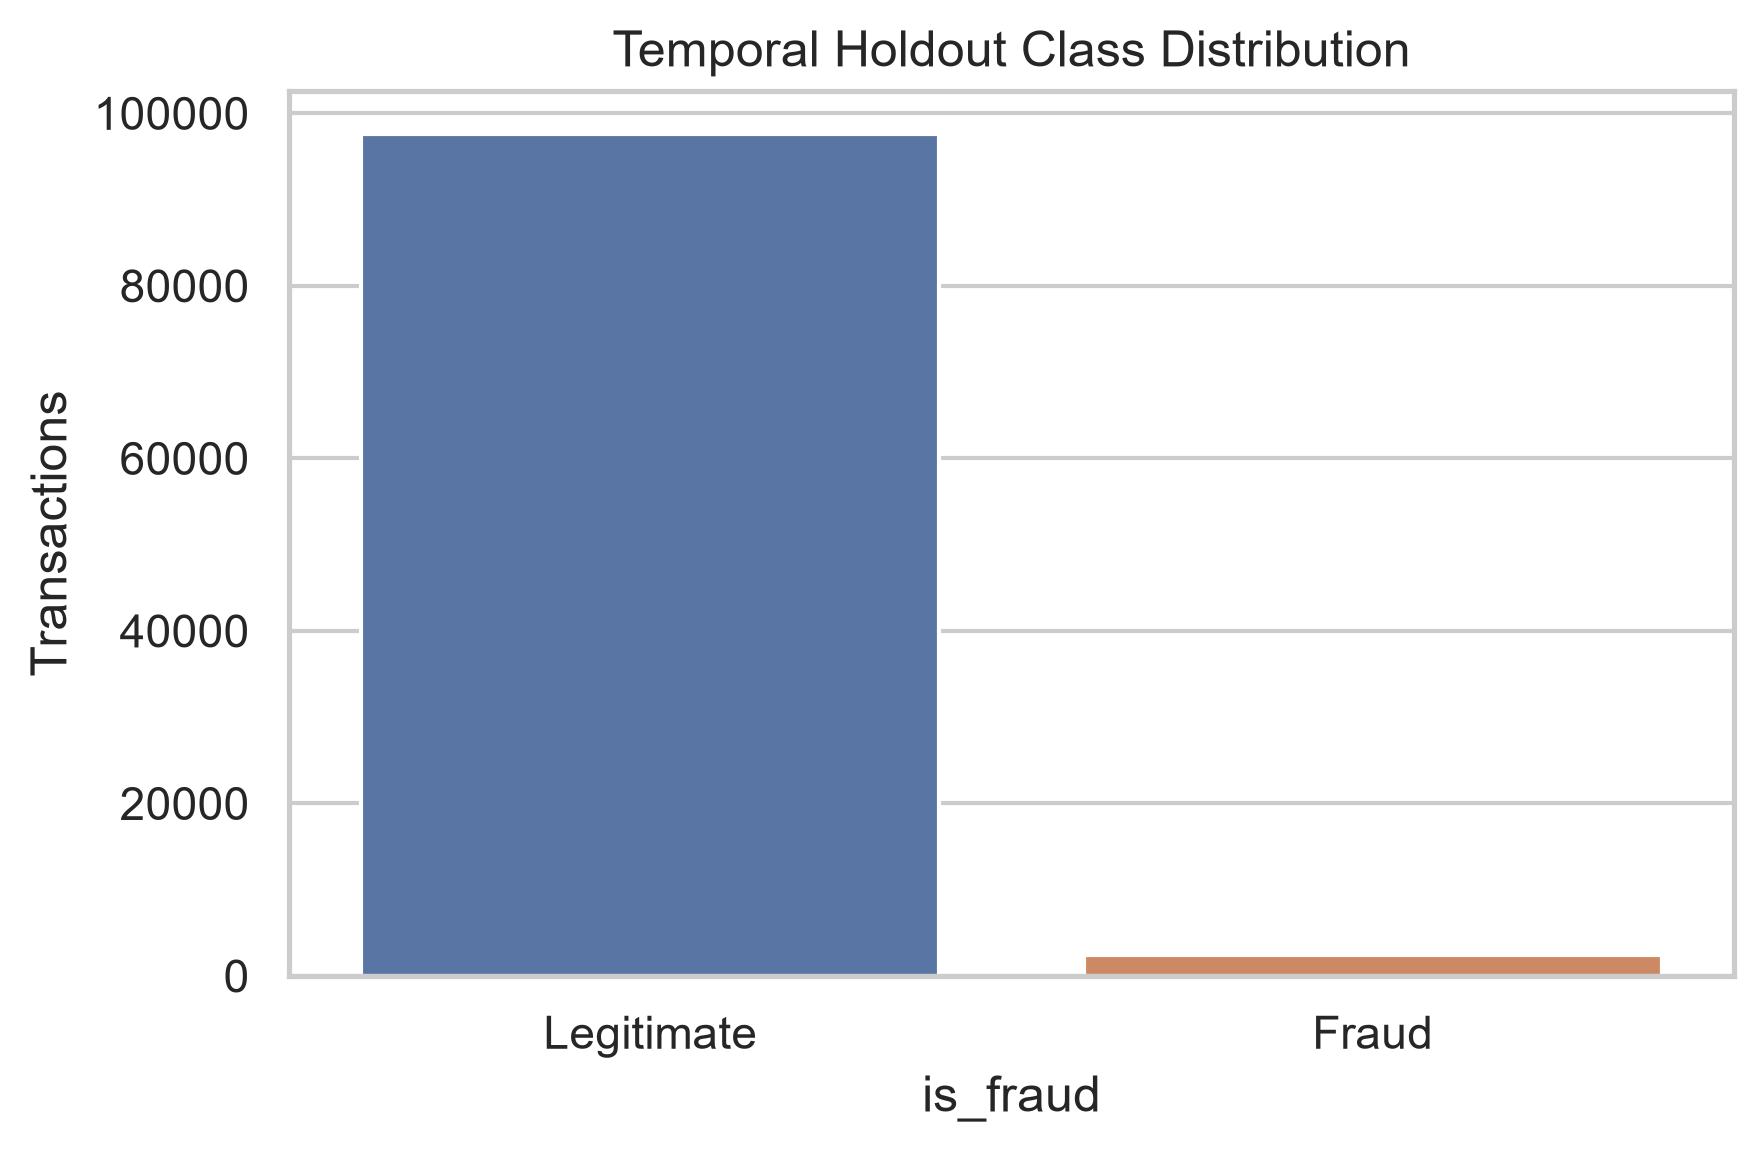

02_confusion_matrix.png


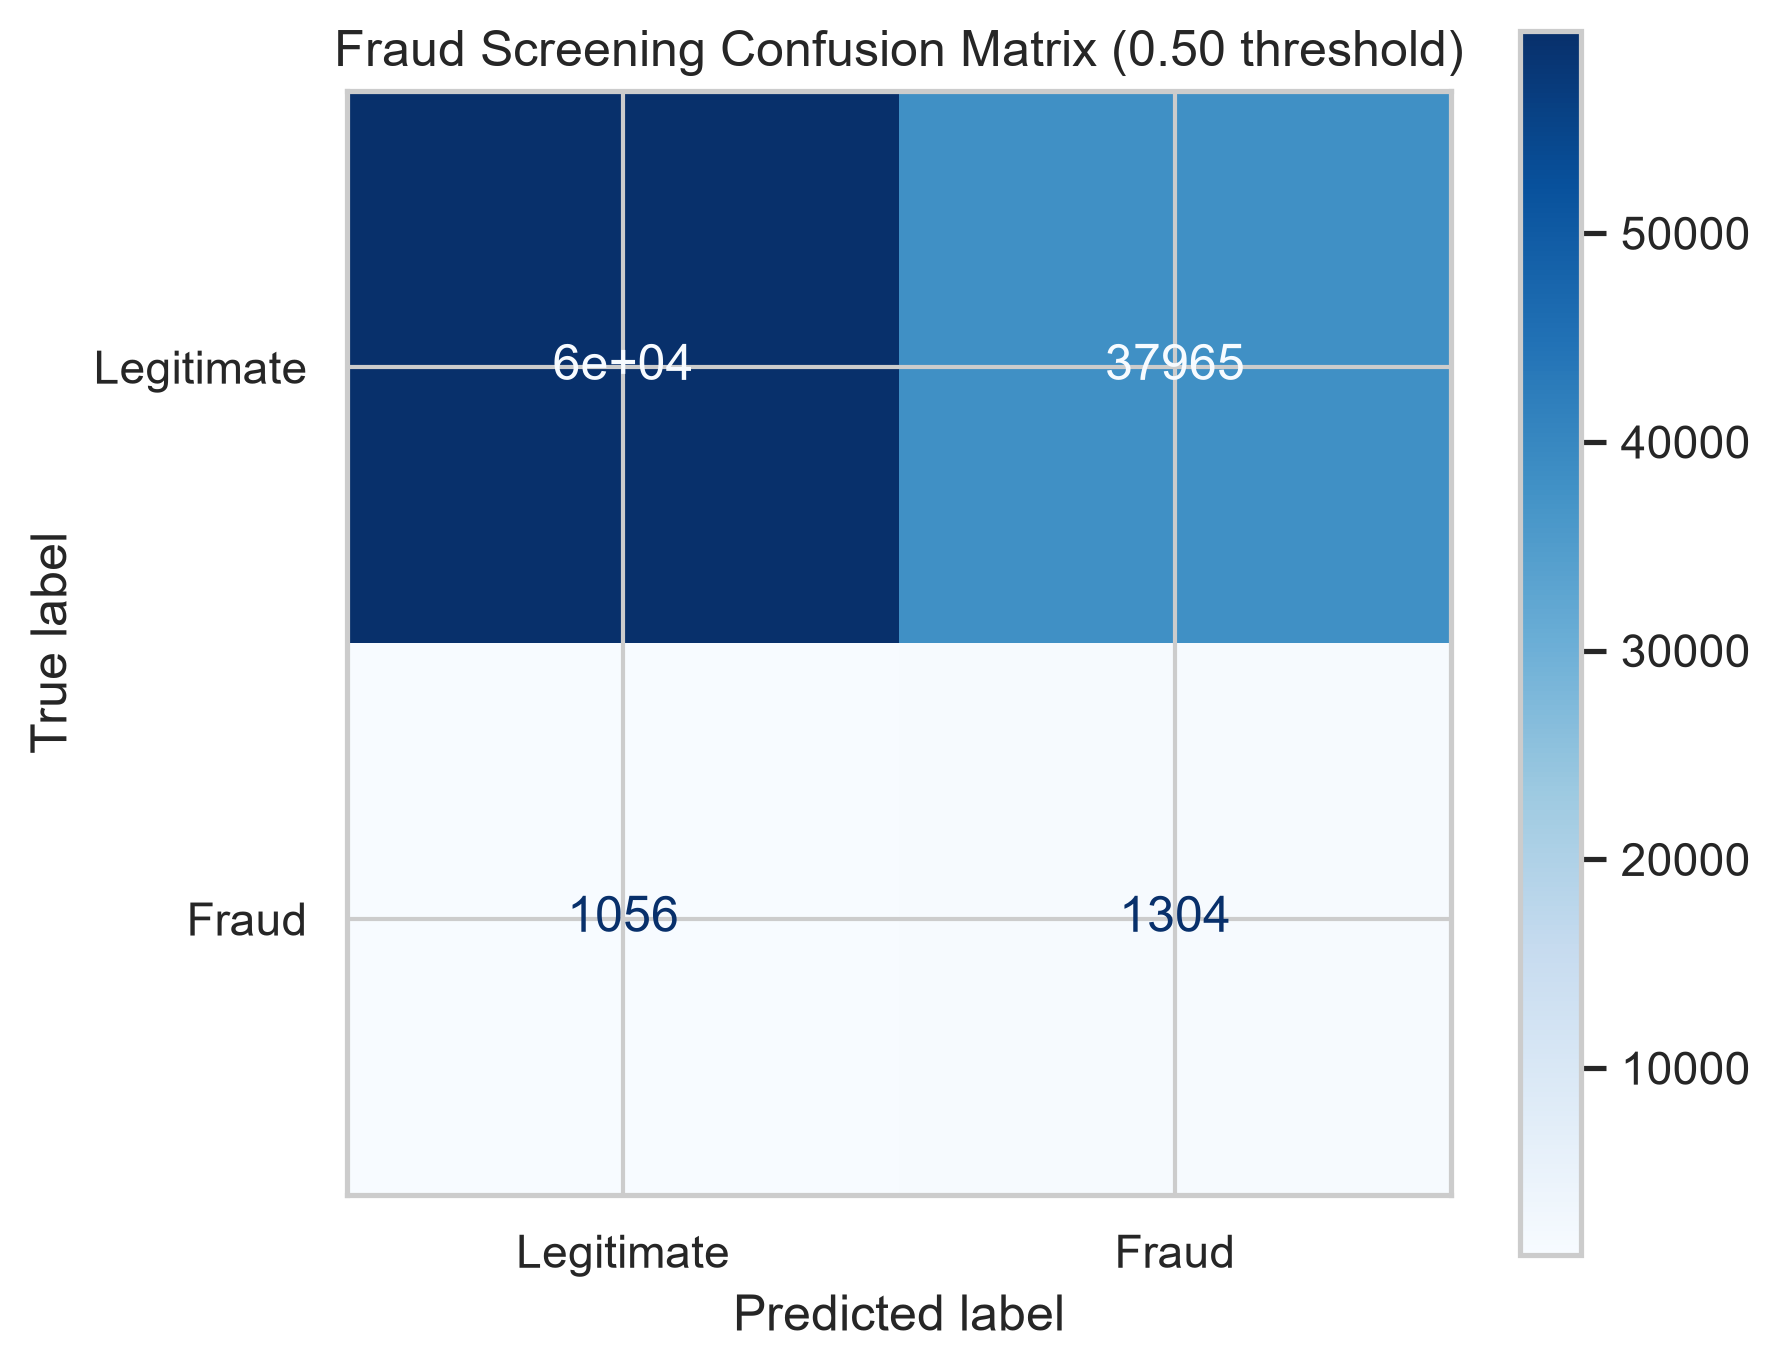

03_roc_curve.png


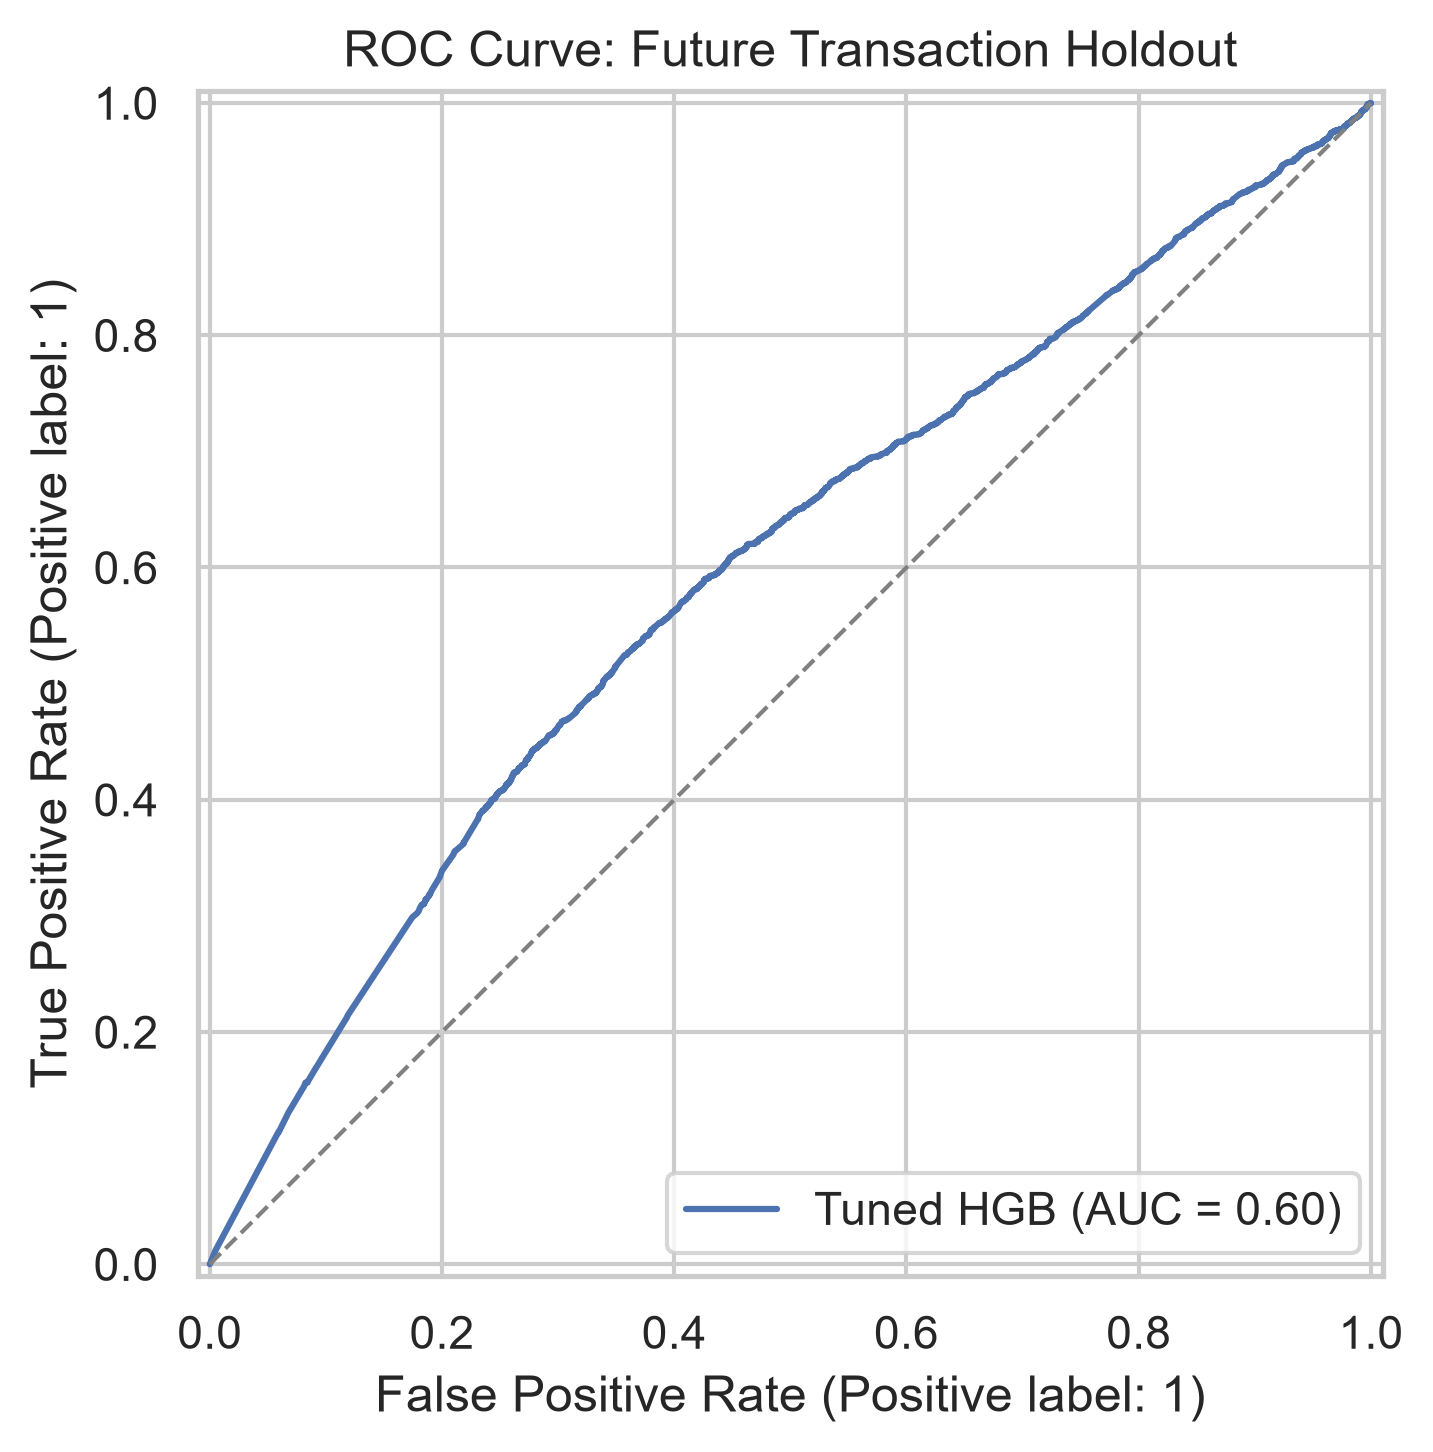

04_precision_recall_curve.png


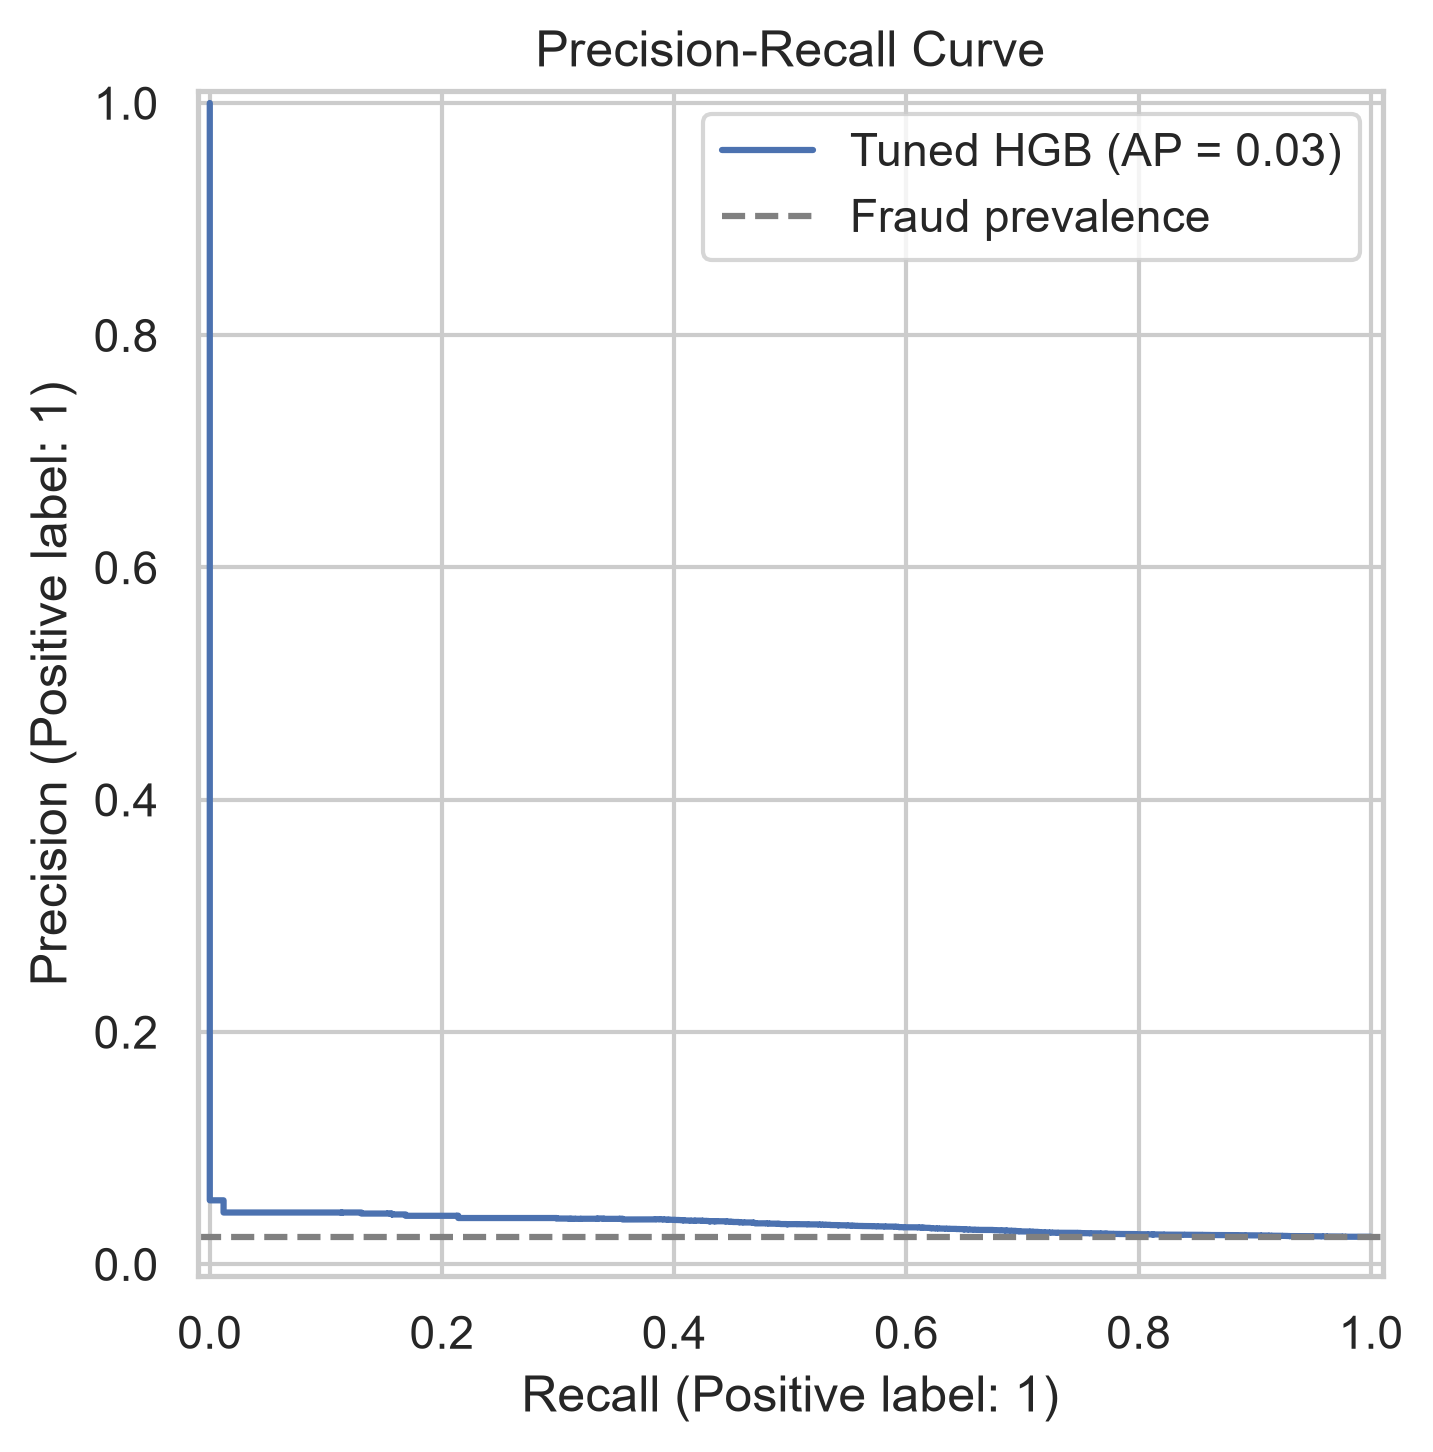

05_permutation_importance.png


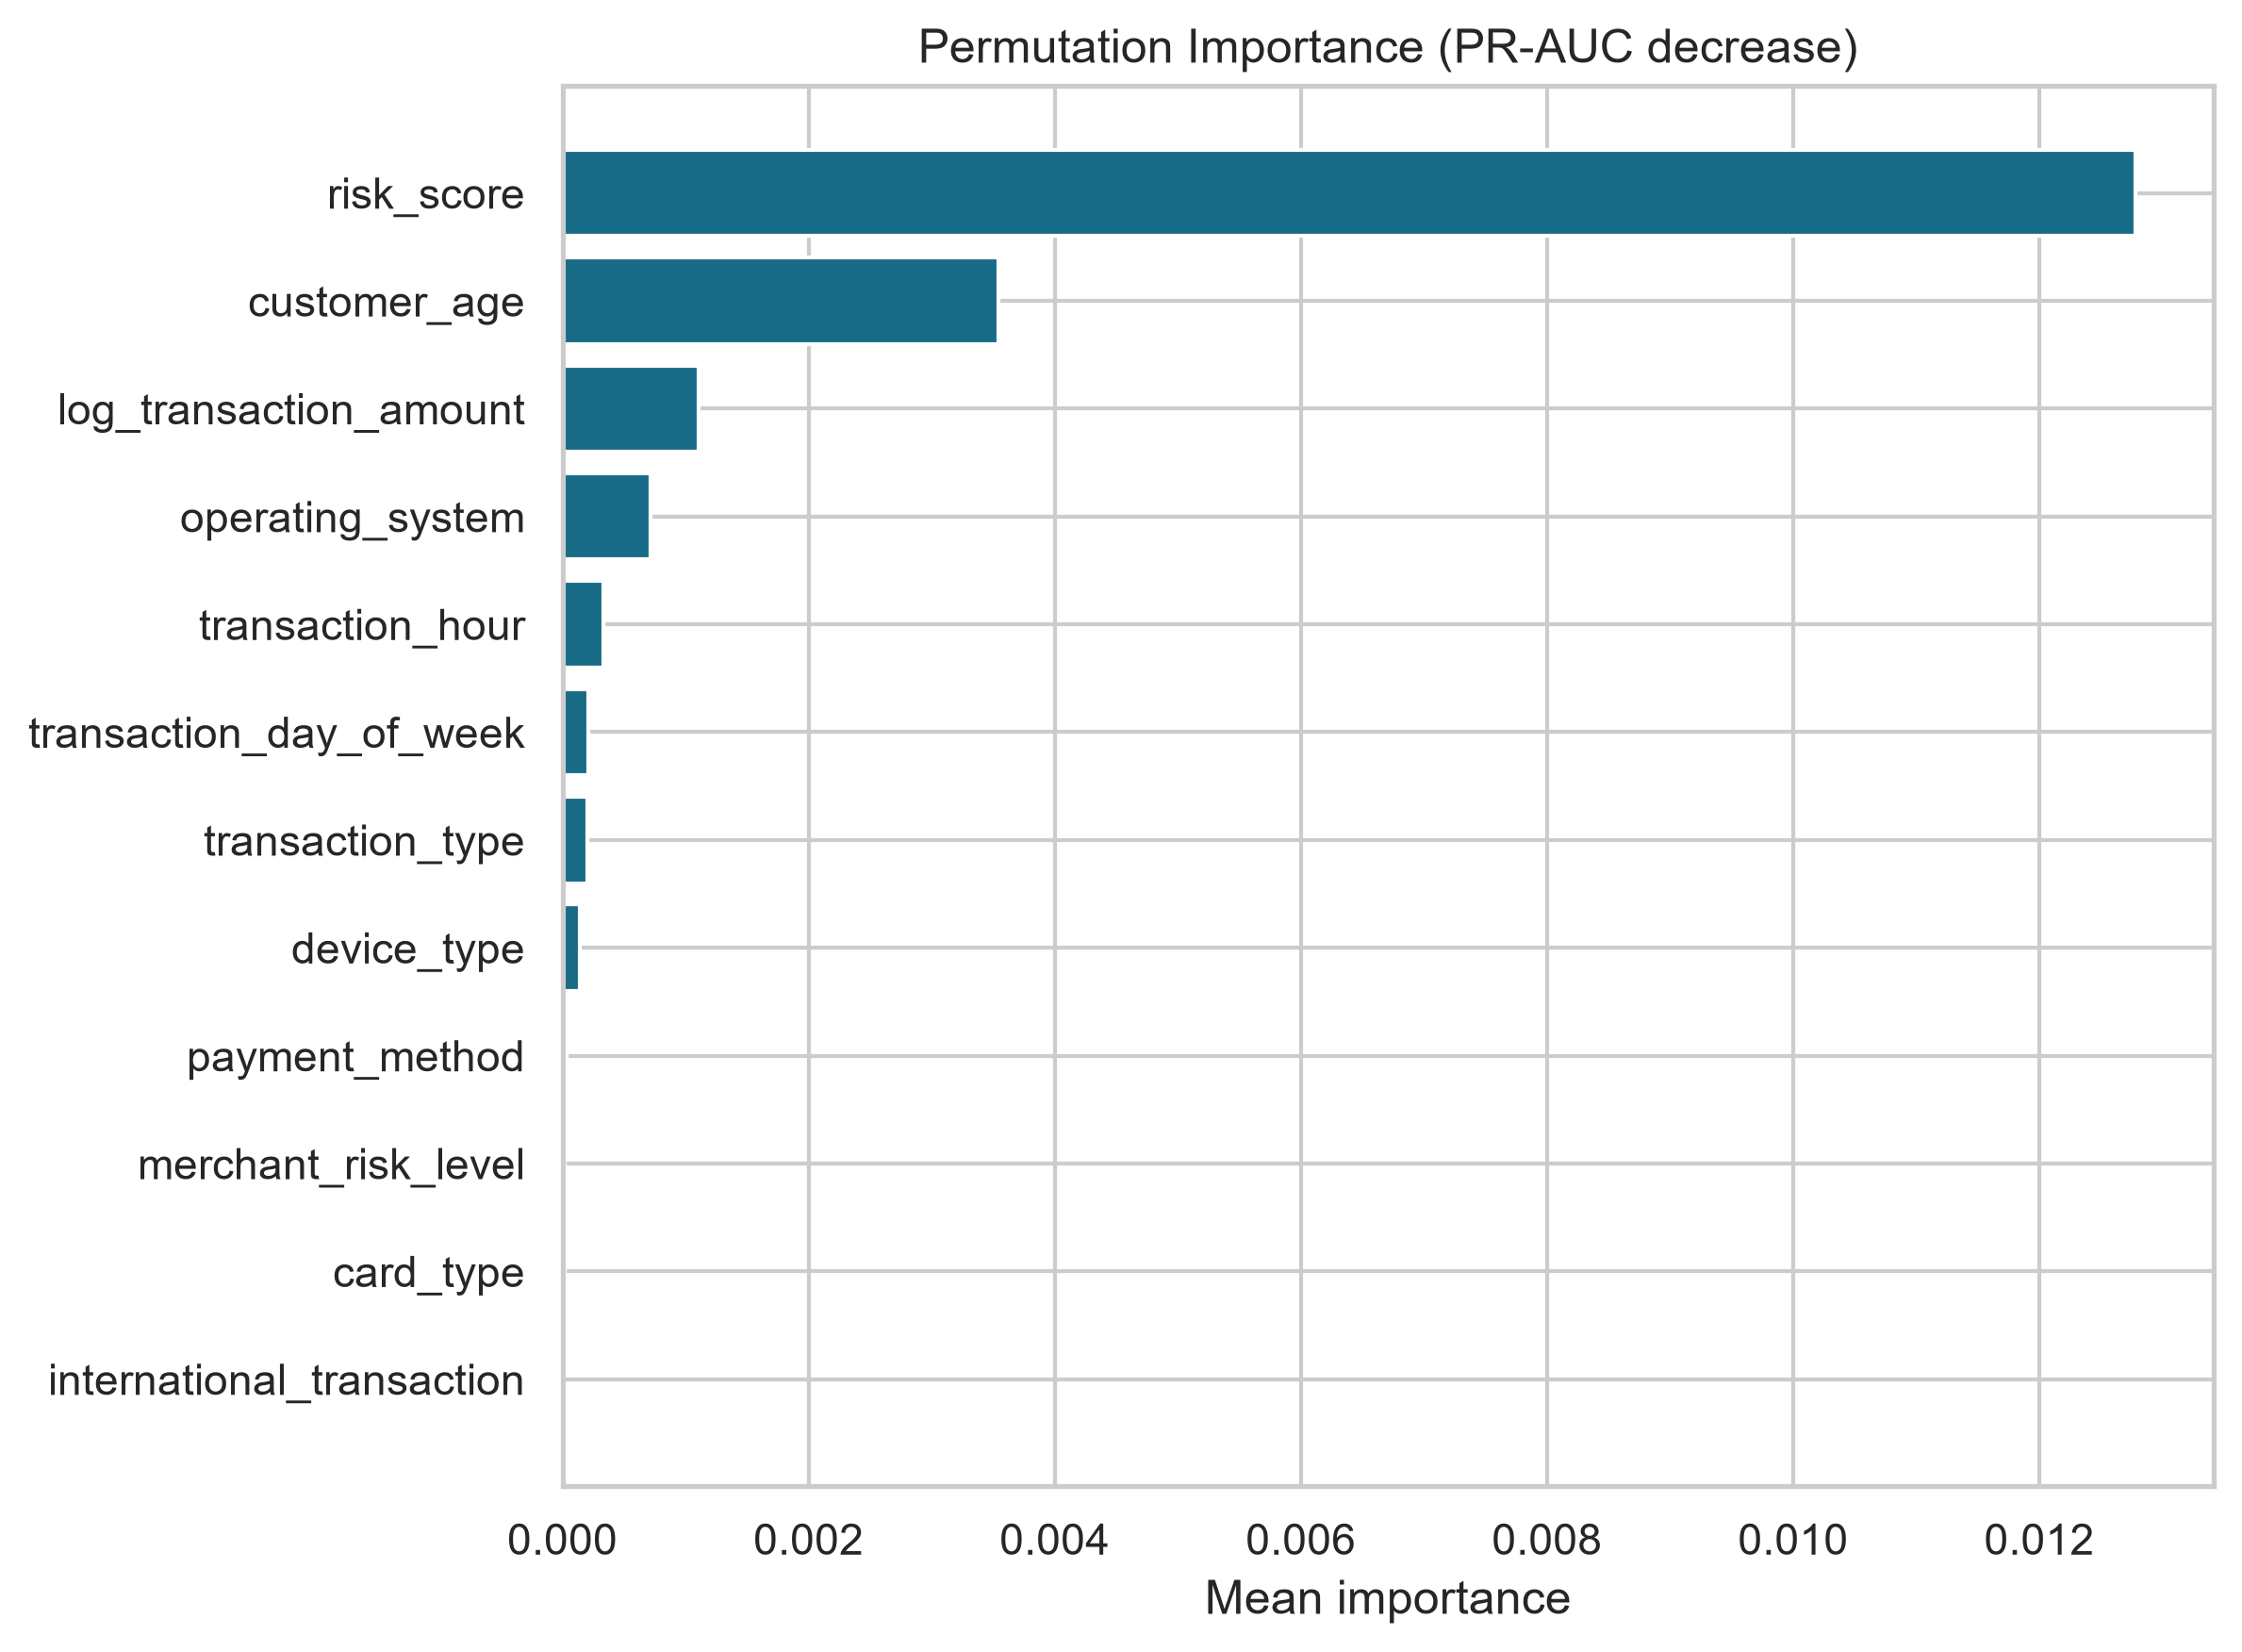

Saved full pipeline: C:\Users\Syed Imad Muzaffar\Downloads\Thiranex\Task 4\models\tuned_fraud_detector.joblib


In [5]:
from IPython.display import Image, display

importance = permutation_feature_importance(best_model, X_test, y_test)
figure_paths = generate_diagnostics(best_model, X_test, y_test, importance, FIGURES_DIR)
save_model(best_model, MODEL_PATH)
display(importance.head(12))
for path in figure_paths:
    print(path.name)
    display(Image(filename=str(path)))
print('Saved full pipeline:', MODEL_PATH)


## 5. Responsible Deployment

The model is a screening aid, not an automatic denial engine. Before deployment, select an operating threshold using fraud-loss and review-cost evidence, monitor input/performance drift, audit fairness, and enforce real-time latency and human-review controls.
